#introducao 

nesse notebook, iremos plotar alguns graficos e analisar o comportamento dos datasets de componentes curriculares dos modelos:EAD,presencial e semi-presenciais

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [46]:
df = pd.read_csv(os.path.join("..","dataset","componentes.csv"))
df.head(10)

,id_componente,tipo_componente,codigo,nivel,nome,unidade_responsavel,ch_teorico,ch_pratico,ch_estagio,ch_total,...,ementa,bibliografia,objetivos,conteudo,competencias_habilidades,referencias,ano_programa,periodo_programa,modalidade,curso_componente
0,54409,MÓDULO,EM 2143,L,Pedagogia e Fazeres em Educação Musical IV,ESCOLA DE MÚSICA,40,0,0,40,...,Concepção e execução de musicais didáticos com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...
1,54410,MÓDULO,EM 2144,L,Pesquisa em Música I,ESCOLA DE MÚSICA,40,0,0,40,...,"Os fundamentos, as principais definições metod...",NaN,Proporcionar ao aluno fundamentos e caminhos p...,"- Conceito de conhecimento, pesquisa ...",- Ser capaz de compreender elementos...,NaN,2013.0,2.0,Semi-Presencial,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...
2,54411,MÓDULO,EM 2145,L,O ENSINO DE MÚSICA NA CONTEMPORANEIDADE,ESCOLA DE MÚSICA,40,0,0,40,...,Os paradigmas contemporâneos para a Educação M...,NaN,Os paradigmas contemporâneos para a Educação M...,. considerações sobre as grandes mudanças ocor...,Consciência das alterações nos modos de compre...,NaN,2013.0,2.0,Semi-Presencial,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...
3,54412,MÓDULO,EM 2146,L,Ensino de Música e o Contexto Escolar,ESCOLA DE MÚSICA,40,0,0,40,...,Os aspectos teórico-metodológicos no Ensino de...,NaN,Os aspectos teórico-metodológicos no Ensino de...,Os aspectos teórico-metodológicos no Ensino de...,Percepção de pontos de contato e de distanciam...,NaN,2013.0,2.0,Semi-Presencial,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...
4,54415,MÓDULO,EM 2147,L,PEDAGOGIA E FAZERES EM EDUCAÇÃO MUSICAL I,ESCOLA DE MÚSICA,40,0,0,40,...,Vivências rítmico-sonoras em educação musical....,NaN,*\tAnalisar e discutir os pressupostos teórico...,* Tópicos em educação musical:\r\nAprofundamen...,*\tCompreender os pressupostos teóricos e meto...,NaN,2013.0,2.0,Semi-Presencial,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...
5,54419,MÓDULO,DMP0001,L,LEITURA E PRODUÇÃO DE TEXTOS EM EDUCAÇÃO AMBIE...,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,36,9,0,45,...,Gêneros e tipos textuais. Estratégias de leitu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...
6,54420,MÓDULO,DMP0002,L,INTRODUÇÃO A EDUCAÇÃO AMBIENTAL,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,36,9,0,45,...,Origens do conceito de sustentabilidade. EA e ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...
7,54421,MÓDULO,DMP0003,L,METODOLOGIA DO TRABALHO CIENTÍFICO,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,36,9,0,45,...,Fundamentos da metodologia científica. A comun...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...
8,54422,MÓDULO,DMP0004,L,DESENVOLVIMENTO DE PROJETOS SOCIOAMBIENTAIS NA...,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,36,9,0,45,...,Metodologias de Pesquisa participativa. Percep...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...
9,54423,MÓDULO,DMP0005,L,EDUCAÇÃO AMBIENTAL PARA A SUSTENTABILIDADE,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,36,9,0,45,...,Conceitos básicos de ecologia. Poluição do sol...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Semi-Presencial,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...


In [47]:
missing_ano_programa = df['ano_programa'].isna()

print(f"Total rows: {len(df)}")
print(f"Rows with missing 'ano_programa': {missing_ano_programa.sum()}\n")

missing_in_ano_missing = df[missing_ano_programa].isna().sum()
missing_pct = (missing_in_ano_missing / missing_ano_programa.sum() * 100).round(2)
summary = pd.DataFrame({
    'missing_count_in_rows_with_no_ano': missing_in_ano_missing,
    'pct_in_those_rows': missing_pct
}).sort_values('missing_count_in_rows_with_no_ano', ascending=False)

print("Columns missing among rows with missing 'ano_programa':")
print(summary)

sample_cols = [c for c in ['id_componente','curso_componente','modalidade','unidade_responsavel','ch_total','qtd_unidades','ano_programa'] if c in df.columns]
print("\nSample rows with missing 'ano_programa':")
display(df[missing_ano_programa][sample_cols])

Total rows: 48084
Rows with missing 'ano_programa': 33368

Columns missing among rows with missing 'ano_programa':
                          missing_count_in_rows_with_no_ano  pct_in_those_rows
bibliografia                                          33368             100.00
periodo_programa                                      33368             100.00
ano_programa                                          33368             100.00
referencias                                           33328              99.88
conteudo                                              33326              99.87
procedimentos_avaliacao                               33325              99.87
objetivos                                             33324              99.87
competencias_habilidades                              33287              99.76
co_requisito                                          33006              98.92
pre_requisito                                         29206              87.53
equivalencia    

,id_componente,curso_componente,modalidade,unidade_responsavel,ch_total,qtd_unidades,ano_programa
0,54409,ESPECIALIZAÇÃO EM ENSINO DE ARTES NA EDUCAÇÃO ...,Semi-Presencial,ESCOLA DE MÚSICA,40,NaN,NaN
5,54419,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...,Semi-Presencial,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,45,NaN,NaN
6,54420,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...,Semi-Presencial,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,45,NaN,NaN
7,54421,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...,Semi-Presencial,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,45,NaN,NaN
8,54422,ESPECIALIZAÇÃO EM EDUCAÇÃO AMBIENTAL PARA ESCO...,Semi-Presencial,DEPARTAMENTO DE MICROBIOLOGIA E PARASITOLOGIA,45,NaN,NaN
...,...,...,...,...,...,...,...
48070,2046786,NaN,A Distância,DEPARTAMENTO DE CIÊNCIAS ADMINISTRATIVAS - DEPAD,30,1.0,NaN
48075,2046804,NaN,A Distância,DEPARTAMENTO DE CIÊNCIAS ADMINISTRATIVAS - DEPAD,30,1.0,NaN
48076,2046805,NaN,A Distância,DEPARTAMENTO DE CIÊNCIAS ADMINISTRATIVAS - DEPAD,30,1.0,NaN
48078,2047051,NaN,A Distância,DEPARTAMENTO DE CIÊNCIAS ADMINISTRATIVAS - DEPAD,30,1.0,NaN


In [48]:
df.value_counts('modalidade')

modalidade
Presencial         44525
A Distância         2776
Semi-Presencial      783
Name: count, dtype: int64

notamos aqui a maior presenca dos componentes presenciais no dataset

In [49]:
semi_presencial = df[df['modalidade']=='Semi-presencial']
ead = df[df['modalidade']=='EAD']
presencial = df[df['modalidade']=='Presencial']

In [50]:
presencial[['ch_teorico','ch_pratico']].describe()

,ch_teorico,ch_pratico
count,44525.000000,44525.000000
mean,38.922448,13.556407
std,60.023685,63.606283
min,0.000000,0.000000
25%,15.000000,0.000000
50%,30.000000,0.000000
75%,60.000000,15.000000
max,5760.000000,3568.000000


In [51]:
maiores_cursos = {}
for modalidade in df['modalidade'].unique():
    subset = df[df['modalidade'] == modalidade]
    curso_counts = subset['curso_componente'].value_counts()
    if not curso_counts.empty:
        curso_top = curso_counts.idxmax()
        count_top = curso_counts.max()
        maiores_cursos[modalidade] = (curso_top, count_top)
    else:
        maiores_cursos[modalidade] = (None, 0)

for modalidade, (curso, count) in maiores_cursos.items():
    print(f"Modalidade: {modalidade}\nCurso com maior presença: {curso}\nQuantidade de componentes: {count}\n")

Modalidade: Semi-Presencial
Curso com maior presença: EDUCAÇÃO MIDIÁTICA
Quantidade de componentes: 55

Modalidade: Presencial
Curso com maior presença: LETRAS
Quantidade de componentes: 300

Modalidade: A Distância
Curso com maior presença: ESPECIALIZAÇÃO EM SAÚDE DA FAMÍLIA
Quantidade de componentes: 132



In [52]:
if 'tipo_componente' in df.columns:
    s = df['tipo_componente']
    print(f"Distinct values (n={s.nunique(dropna=True)}):")
    print(sorted(s.dropna().unique()))
    print("\nCounts (including NaN):")
    display(s.value_counts(dropna=False))

Distinct values (n=4):
['ATIVIDADE', 'BLOCO', 'DISCIPLINA', 'MÓDULO']

Counts (including NaN):


tipo_componente
DISCIPLINA    26608
MÓDULO        15618
ATIVIDADE      5530
BLOCO           328
Name: count, dtype: int64

In [53]:
display(df[df['tipo_componente'] == 'DISCIPLINA'].describe())

,id_componente,ch_teorico,ch_pratico,ch_estagio,ch_total,ch_dedicada_docente,ch_ead,cr_max_ead,qtd_unidades,bibliografia,ano_programa,periodo_programa
count,2.660800e+04,26608.000000,26608.000000,26608.000000,26608.000000,26608.000000,26608.000000,26608.0,25098.000000,0.0,10852.000000,10852.000000
mean,3.753697e+05,41.920287,10.198850,1.319829,56.772324,20.150331,1.262327,20.0,2.525381,NaN,2018.266034,1.607814
std,2.557719e+06,26.134510,28.556407,22.241857,34.701058,37.119320,9.082160,0.0,0.828246,NaN,6.315522,0.492956
min,1.864200e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.0,0.000000,NaN,1990.000000,1.000000
25%,2.701075e+04,30.000000,0.000000,0.000000,45.000000,0.000000,0.000000,20.0,2.000000,NaN,2011.000000,1.000000
50%,4.849850e+04,45.000000,0.000000,0.000000,60.000000,0.000000,0.000000,20.0,3.000000,NaN,2021.000000,2.000000
75%,6.894825e+04,60.000000,15.000000,0.000000,60.000000,45.000000,0.000000,20.0,3.000000,NaN,2024.000000,2.000000
max,1.082761e+08,675.000000,2268.000000,2268.000000,2268.000000,2268.000000,120.000000,20.0,3.000000,NaN,2025.000000,5.000000


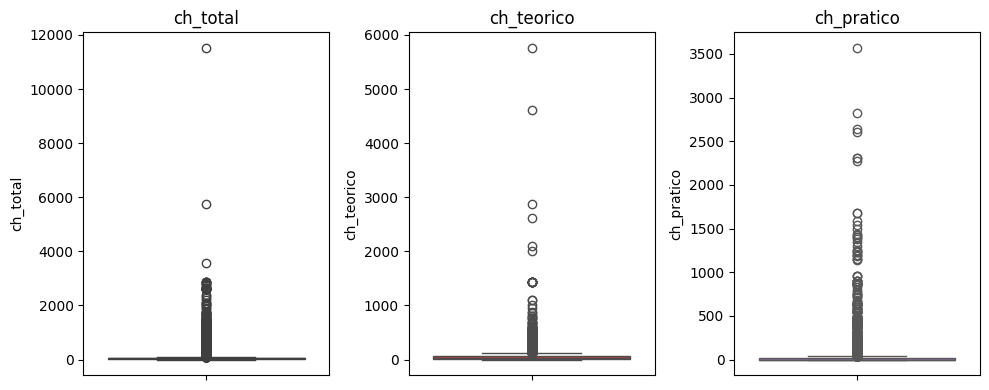

In [54]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['ch_total'].dropna(), color='C0')
plt.title('ch_total')
plt.subplot(1, 3, 2)
sns.boxplot(df['ch_teorico'].dropna(), color='C3')
plt.title('ch_teorico')
plt.subplot(1, 3, 3)
sns.boxplot(df['ch_pratico'].dropna(), color='C4')
plt.title('ch_pratico')
plt.tight_layout()

notamos a 

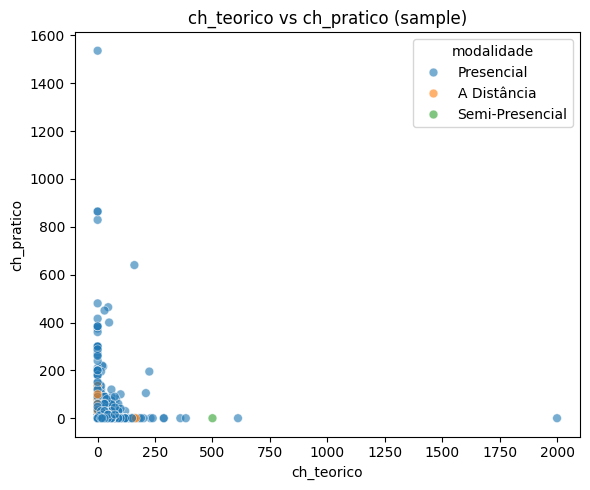

In [55]:
sample = df[['ch_teorico','ch_pratico','modalidade']].dropna().sample(n=min(3000, len(df)), random_state=1)
plt.figure(figsize=(6,5))
sns.scatterplot(data=sample, x='ch_teorico', y='ch_pratico', hue='modalidade', alpha=0.6, s=40, legend='brief')
plt.title('ch_teorico vs ch_pratico (sample)')
plt.tight_layout()

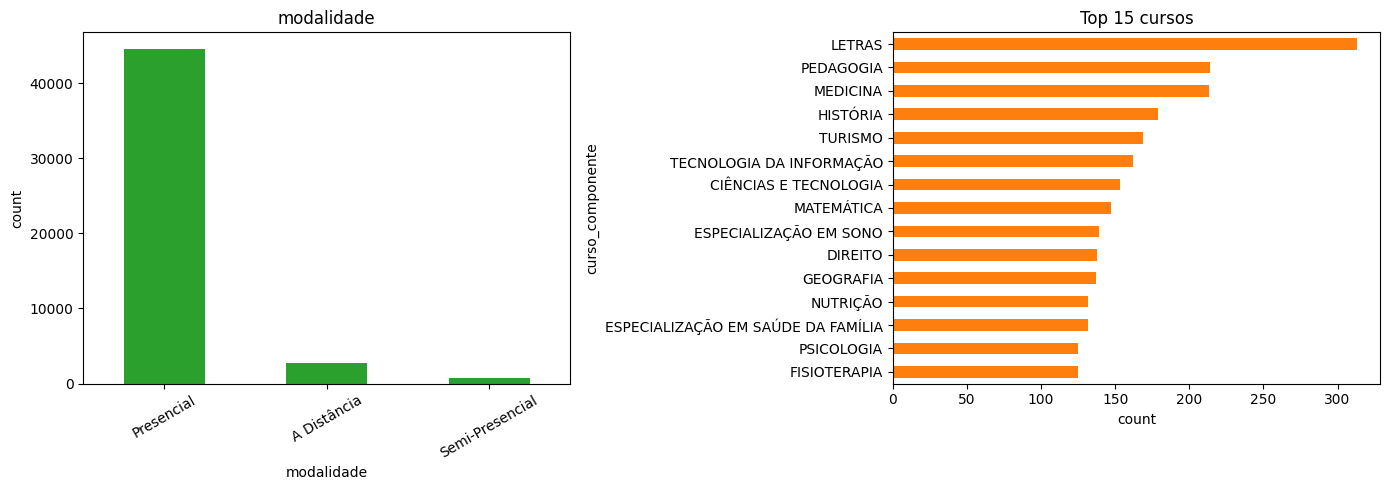

In [59]:
modality_counts = df['modalidade'].value_counts()
top_courses = df['curso_componente'].value_counts().nlargest(15)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
modality_counts.plot(kind='bar', color='C2')
plt.title('modalidade')
plt.ylabel('count')
plt.xticks(rotation=30)

plt.subplot(1,2,2)
top_courses.plot(kind='barh', color='C1')
plt.title('Top 15 cursos')
plt.xlabel('count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

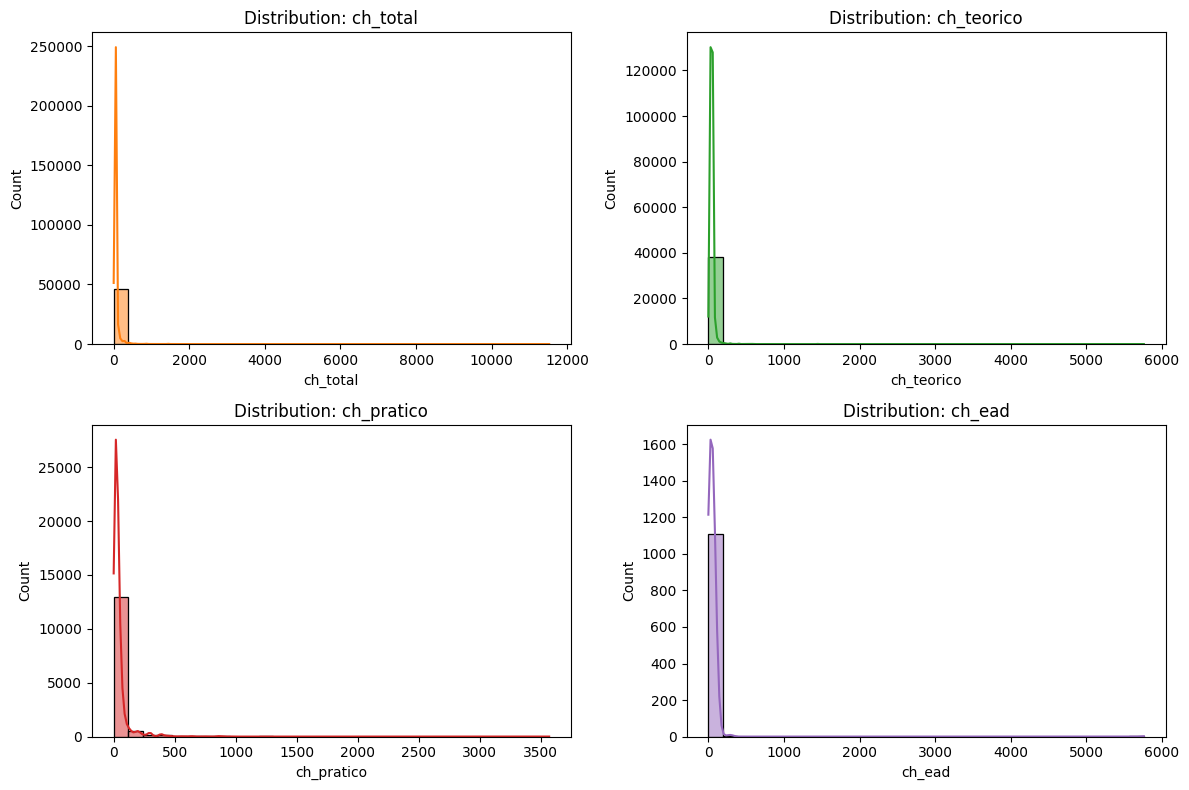

In [60]:
cols = [c for c in ['ch_total','ch_teorico','ch_pratico','ch_ead'] if c in df.columns]
plt.figure(figsize=(12,8))
for i, c in enumerate(cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(df[c].replace(0, pd.NA).dropna(), kde=True, bins=30, color=f'C{i}')
    plt.title(f'Distribution: {c}')
plt.tight_layout()
plt.show()

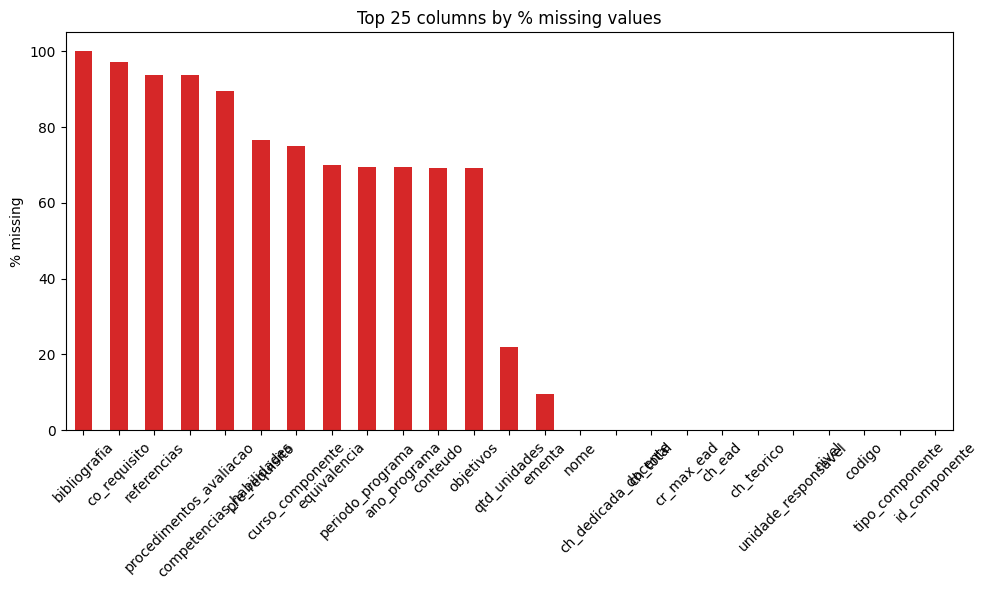

In [62]:
miss_pct = df.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10,6))
miss_pct.head(25).plot(kind='bar', color='C3')
plt.title('Top 25 columns by % missing values')
plt.ylabel('% missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

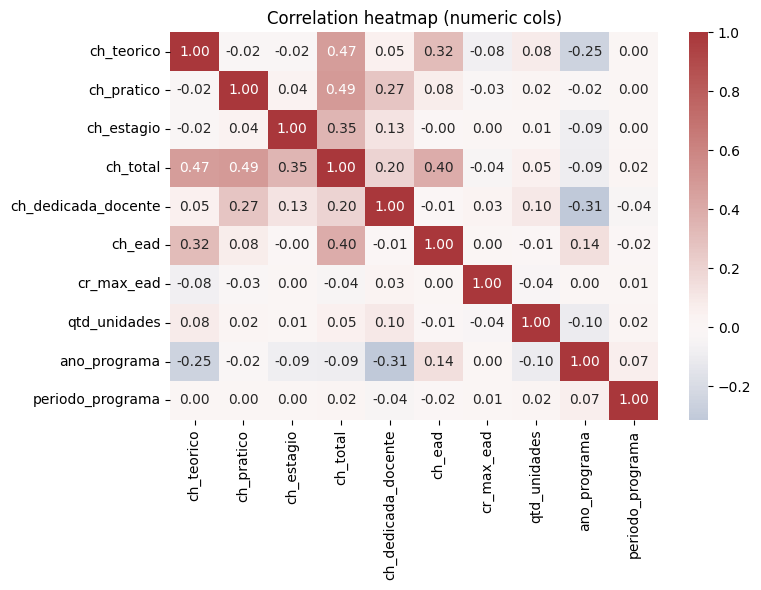

In [56]:

num_cols = ['ch_teorico','ch_pratico','ch_estagio','ch_total','ch_dedicada_docente','ch_ead','cr_max_ead','qtd_unidades','ano_programa','periodo_programa']
num_present = [c for c in num_cols if c in df.columns]
corr = df[num_present].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0)
plt.title('Correlation heatmap (numeric cols)')
plt.tight_layout()
plt.show()